In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import torch

data = pd.read_csv('./Updated Data/power_data_handle.csv')
data.info()

X = data[['length', 'breadth', 'gross_tonnage', 'deadweight'
         ,'type_no'
         ]].values
y = data['engine_power'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#随机森林模型
rf_model = RandomForestRegressor(n_estimators=100)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

while(1):
    rf_model.fit(X_train, y_train)

    #测试集进行预测
    y_pred_rf = rf_model.predict(X_test)

    y_pred_rf_tensor = torch.tensor(y_pred_rf, dtype=torch.float32).view(-1, 1)

    #评估指标
    rf_mse = mean_squared_error(y_test, y_pred_rf)
    rf_r2 = r2_score(y_test, y_pred_rf)
    
    if(rf_r2>0.925): break
#结果
print('使用随机森林模型得到的平均误差平方（MSE）：', rf_mse)
print('使用随机森林模型得到的决定系数（R^2值）：', rf_r2)

D:\Anaconda3\envs\ai\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10043 entries, 0 to 10042
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0.1   10043 non-null  int64  
 1   Unnamed: 0     10043 non-null  int64  
 2   type_no        10043 non-null  int64  
 3   length         10043 non-null  float64
 4   breadth        10043 non-null  float64
 5   draught        10043 non-null  float64
 6   gross_tonnage  10043 non-null  float64
 7   deadweight     10043 non-null  float64
 8   engine_power   10043 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 706.3 KB
使用随机森林模型得到的平均误差平方（MSE）： 18949904.485709287
使用随机森林模型得到的决定系数（R^2值）： 0.9253748250067314


In [7]:
csv_data=pd.read_csv('./Updated Data/co2_data_1207.csv')
csv_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9167 entries, 0 to 9166
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      9167 non-null   int64  
 1   Ship type                       9167 non-null   object 
 2   length                          7919 non-null   float64
 3   breadth                         7919 non-null   float64
 4   gross_tonnage                   7926 non-null   float64
 5   deadweight                      7921 non-null   float64
 6   max_speed                       9167 non-null   float64
 7   avg_speed                       9167 non-null   float64
 8   Time spent at sea [hours]       9167 non-null   float64
 9   Total CO₂ emissions [m tonnes]  9167 non-null   float64
 10  type no                         9167 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 787.9+ KB


In [54]:
import pickle

# 保存模型
save_path = './rf_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(rf_model, f)

In [9]:
import pickle
import pandas as pd

# csv_data=pd.read_csv('./Updated Data/will_use_co2.csv')
# /csv_data=pd.read_csv('./Updated Data/co2_data_1207.csv')
csv_data=pd.read_csv('step2_data_0121.csv')

csv_data.info()
new_data = csv_data[['length', 'breadth', 'gross_tonnage', 'deadweight','type no']]

# 加载模型
with open('./rf_model.pkl', 'rb') as f:
    loaded_rf_model = pickle.load(f)

# 使用加载的模型进行预测
predicted_value = loaded_rf_model.predict(new_data)
print("预测值：", predicted_value)

csv_data['engine_power'] = predicted_value

csv_data.info()

csv_data.to_csv('./Updated Data/co2_0122.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7918 entries, 0 to 7917
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      7918 non-null   int64  
 1   length                          7918 non-null   float64
 2   breadth                         7918 non-null   float64
 3   gross_tonnage                   7918 non-null   float64
 4   deadweight                      7918 non-null   float64
 5   avg_speed                       7918 non-null   float64
 6   Time spent at sea [hours]       7918 non-null   float64
 7   Total CO₂ emissions [m tonnes]  7918 non-null   float64
 8   type no                         7918 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 556.9 KB
预测值： [12051.96        6153.6         6210.34       ...  6399.62
  7802.25        3964.40666667]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7918 entries, 0 to 7917
D

D:\Anaconda3\envs\ai\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [89]:

# plt.figure(figsize=(14, 8))

# # 绘制散点图，不同种类的用不同颜色表示
# for ship_type in csv_data['Ship type'].unique():
#     ship_data = csv_data[csv_data['Ship type'] == ship_type]
#     plt.scatter(ship_data['Time spent at sea [hours]'], ship_data['Total CO₂ emissions [m tonnes]'], label=ship_type)

# # 设置标题和轴标签
# plt.title('time vs CO₂')
# plt.xlabel('time')
# plt.ylabel('co2')

# # 添加图例
# plt.legend()

# # 显示图形
# plt.show()

KeyError: 'Ship type'

<Figure size 1008x576 with 0 Axes>

In [87]:
import pandas as pd

#加载 csv 文件,第一行为表头
csv_data = pd.read_csv('./Old Data/dropped_data.csv')
csv_data=csv_data[['Ship type','length', 'breadth', 'gross_tonnage', 'deadweight',
                   'engine_power',
                   'max_speed','avg_speed','Time spent at sea [hours]',
                  'Total CO₂ emissions [m tonnes]']]
csv_data.info()
# csv_data.to_csv('./Old Data/data.csv')

# csv_data=pd.read_csv('./Old Data/data.csv')
# 统计不同 Ship type 的出现次数
ship_type_counts = csv_data['Ship type'].value_counts().reset_index(name='counts')

# 将每种 Ship type 打印出来
print("")
for i, row in ship_type_counts.iterrows():
    print(f'{row["index"]}:  {row["counts"]}')
#     print(row)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12224 entries, 0 to 12223
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Ship type                       12224 non-null  object 
 1   length                          10756 non-null  float64
 2   breadth                         10756 non-null  float64
 3   gross_tonnage                   10764 non-null  float64
 4   deadweight                      10759 non-null  float64
 5   engine_power                    4575 non-null   object 
 6   max_speed                       10139 non-null  object 
 7   avg_speed                       10139 non-null  object 
 8   Time spent at sea [hours]       12224 non-null  float64
 9   Total CO₂ emissions [m tonnes]  12224 non-null  float64
dtypes: float64(6), object(4)
memory usage: 955.1+ KB

Bulk carrier:  3732
Oil tanker:  1851
Container ship:  1834
Chemical tanker:  1387
General cargo ship:  

In [68]:
# 定义一个函数来删除字符串中的非字母字符
def clean_data(data):
    cleaned_data = ''.join(e for e in data if e.isalnum())
    return cleaned_data

# 将 Ship type 列的数据转换为字符串类型
# csv_data['Ship type'] = csv_data['Ship type'].astype(str)

# 对 Ship type 列中的所有内容应用上述函数进行清洗
# csv_data['Ship type'] = csv_data['Ship type'].apply(clean_data)

# 设置类别与数字映射关系的字典
type_no_mapping = {'Bulk carrier': 0,
                   'Chemical tanker': 1,
                   'Combination carrier': 2,
                   'Container/ro-ro cargo ship': 3,
                   'Container ship': 4,
                   'Gas carrier': 5,
                   'General cargo ship': 6,
                   'LNG carrier': 7,
                   'Oil tanker': 8,
                   'Passenger ship': 9,
                   'Refrigerated cargo carrier': 10,
                   'Ro-pax ship': 11,
                   'Ro-ro ship': 12}

# 对 Ship type 列应用映射字典
csv_data['type no'] = csv_data['Ship type'].map(type_no_mapping)
csv_data = csv_data.dropna(subset=['type no'])
# 输出结果
# print('根据分类规则在数据集中新增 type no 列的前 10 行内容为：')
# print(csv_data[['Ship type', 'type no']].head(10))

In [70]:
csv_data.info()
# 将 max_speed 和 avg_speed 列的数据转换为数字类型
csv_data['max_speed'] = pd.to_numeric(csv_data['max_speed'], errors='coerce')
csv_data['avg_speed'] = pd.to_numeric(csv_data['avg_speed'], errors='coerce')
csv_data.info()
csv_data = csv_data.dropna(subset=['max_speed'])
csv_data = csv_data.dropna(subset=['avg_speed'])
csv_data.info()
csv_data.to_csv('./Old Data/data.csv')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9608 entries, 1 to 12223
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Ship type                       9608 non-null   object 
 1   length                          8313 non-null   float64
 2   breadth                         8313 non-null   float64
 3   gross_tonnage                   8320 non-null   float64
 4   deadweight                      8315 non-null   float64
 5   engine_power                    3507 non-null   object 
 6   max_speed                       9608 non-null   object 
 7   avg_speed                       9167 non-null   float64
 8   Time spent at sea [hours]       9608 non-null   float64
 9   Total CO₂ emissions [m tonnes]  9608 non-null   float64
 10  type no                         9608 non-null   float64
dtypes: float64(8), object(3)
memory usage: 900.8+ KB
<class 'pandas.core.frame.DataFrame'>
Int64In

In [77]:
co2_data = csv_data.drop(columns=['engine_power'])
# co2_data = csv_data.drop(columns=['Ship type'])
co2_data.to_csv('./Updated Data/co2_data_1207.csv')
co2_data.dropna()
co2_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9167 entries, 1 to 12223
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Ship type                       9167 non-null   object 
 1   length                          7919 non-null   float64
 2   breadth                         7919 non-null   float64
 3   gross_tonnage                   7926 non-null   float64
 4   deadweight                      7921 non-null   float64
 5   max_speed                       9167 non-null   float64
 6   avg_speed                       9167 non-null   float64
 7   Time spent at sea [hours]       9167 non-null   float64
 8   Total CO₂ emissions [m tonnes]  9167 non-null   float64
 9   type no                         9167 non-null   float64
dtypes: float64(9), object(1)
memory usage: 787.8+ KB


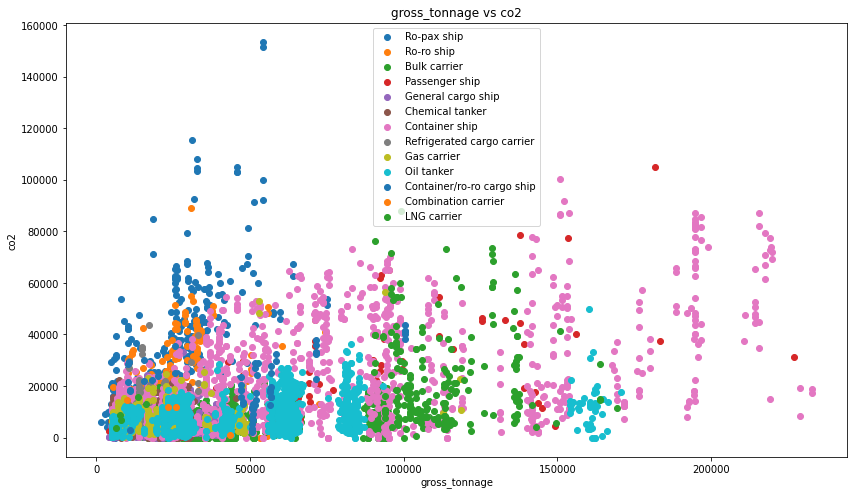

In [85]:
# 船只吨位和CO2排放
csv_data=co2_data
import matplotlib.pyplot as plt

# 显示图形中的中文
# plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']

plt.figure(figsize=(14, 8))


for ship_type in csv_data['Ship type'].unique():
    ship_data = csv_data[csv_data['Ship type'] == ship_type]
    plt.scatter(ship_data['gross_tonnage'], ship_data['Total CO₂ emissions [m tonnes]'], label=ship_type)

plt.title('gross_tonnage vs co2')
plt.xlabel('gross_tonnage')
plt.ylabel('co2')
plt.legend()
plt.show()



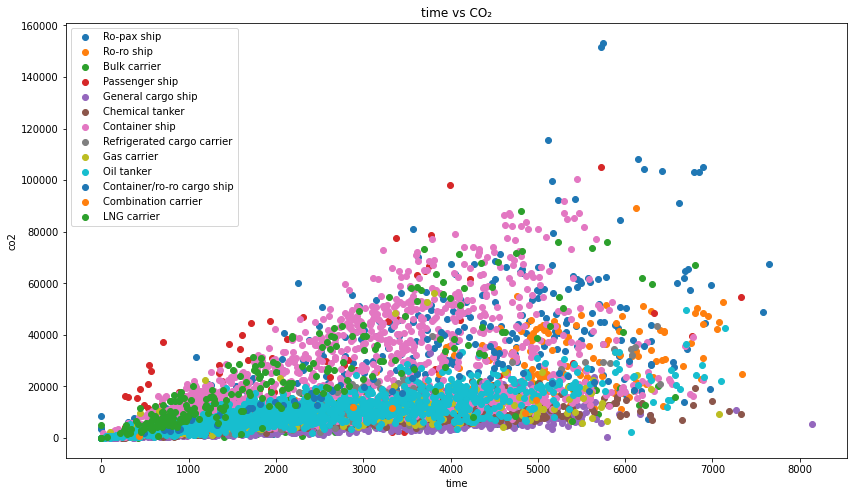

In [86]:
#航行时间和CO2
plt.figure(figsize=(14, 8))

# 绘制散点图
for ship_type in csv_data['Ship type'].unique():
    ship_data = csv_data[csv_data['Ship type'] == ship_type]
    plt.scatter(ship_data['Time spent at sea [hours]'], ship_data['Total CO₂ emissions [m tonnes]'], label=ship_type)

plt.title('time vs CO₂')
plt.xlabel('time')
plt.ylabel('co2')
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(14, 8))

# 绘制散点图，不同种类的用不同颜色表示
for ship_type in csv_data['Ship type'].unique():
    ship_data = csv_data[csv_data['Ship type'] == ship_type]
    plt.scatter(ship_data['Time spent at sea [hours]'], ship_data['Total CO₂ emissions [m tonnes]'], label=ship_type)

# 设置标题和轴标签
plt.title('time vs CO₂')
plt.xlabel('time')
plt.ylabel('co2')

# 添加图例
plt.legend()

# 显示图形
plt.show()